In [1]:
# Import essential libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, DBSCAN
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score


In [2]:
# Load the Excel dataset
file_path = "EastWestAirlines.xlsx"

# Check available sheets
excel_file = pd.ExcelFile(file_path)
print("Sheet Names:", excel_file.sheet_names)

# Load the 'data' sheet
data = pd.read_excel(file_path, sheet_name='data')

# Display first few rows
data.head()


Sheet Names: ['Description', 'data']


,ID#,Balance,Qual_miles,cc1_miles,cc2_miles,cc3_miles,Bonus_miles,Bonus_trans,Flight_miles_12mo,Flight_trans_12,Days_since_enroll,Award?
0,1,28143,0,1,1,1,174,1,0,0,7000,0
1,2,19244,0,1,1,1,215,2,0,0,6968,0
2,3,41354,0,1,1,1,4123,4,0,0,7034,0
3,4,14776,0,1,1,1,500,1,0,0,6952,0
4,5,97752,0,4,1,1,43300,26,2077,4,6935,1


Missing Values:
 Balance              0
Qual_miles           0
cc1_miles            0
cc2_miles            0
cc3_miles            0
Bonus_miles          0
Bonus_trans          0
Flight_miles_12mo    0
Flight_trans_12      0
Days_since_enroll    0
Award?               0
dtype: int64

Data Summary:
             Balance    Qual_miles    cc1_miles    cc2_miles    cc3_miles  \
count  3.999000e+03   3999.000000  3999.000000  3999.000000  3999.000000   
mean   7.360133e+04    144.114529     2.059515     1.014504     1.012253   
std    1.007757e+05    773.663804     1.376919     0.147650     0.195241   
min    0.000000e+00      0.000000     1.000000     1.000000     1.000000   
25%    1.852750e+04      0.000000     1.000000     1.000000     1.000000   
50%    4.309700e+04      0.000000     1.000000     1.000000     1.000000   
75%    9.240400e+04      0.000000     3.000000     1.000000     1.000000   
max    1.704838e+06  11148.000000     5.000000     3.000000     5.000000   

         Bonus_m

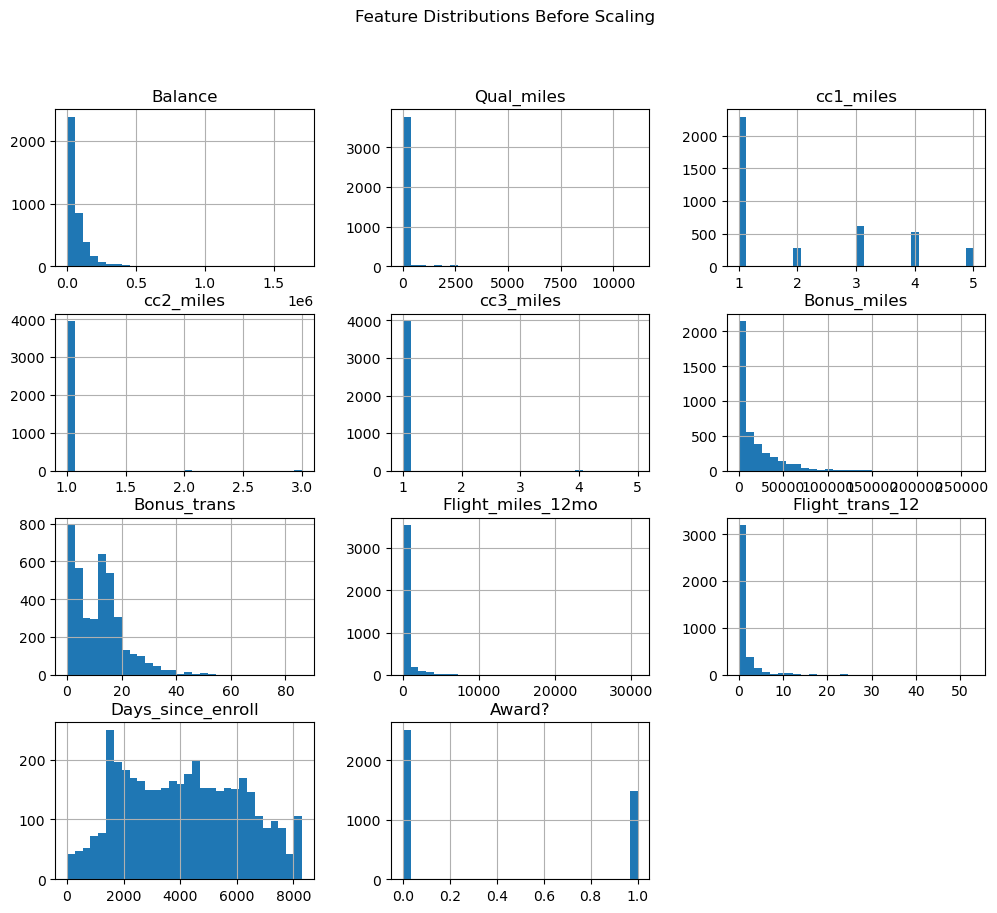

In [3]:
# Drop unnecessary columns like ID#
df = data.drop(columns=['ID#'])

# Check for missing values
print("Missing Values:\n", df.isnull().sum())

# Summary statistics
print("\nData Summary:\n", df.describe())

# Plot histograms for feature distributions
df.hist(figsize=(12, 10), bins=30)
plt.suptitle("Feature Distributions Before Scaling")
plt.show()


In [4]:
# Standardize the data for clustering
scaler = StandardScaler()
scaled_data = scaler.fit_transform(df)

print("Data after scaling:\n", scaled_data[:5])


Data after scaling:
 [[-0.45114078 -0.18629869 -0.76957841 -0.09824189 -0.06276658 -0.70278627
  -1.10406452 -0.32860326 -0.36216787  1.39545434 -0.7669193 ]
 [-0.53945687 -0.18629869 -0.76957841 -0.09824189 -0.06276658 -0.7010884
  -0.99992616 -0.32860326 -0.36216787  1.37995704 -0.7669193 ]
 [-0.32003123 -0.18629869 -0.76957841 -0.09824189 -0.06276658 -0.5392527
  -0.79164945 -0.32860326 -0.36216787  1.41192021 -0.7669193 ]
 [-0.58379852 -0.18629869 -0.76957841 -0.09824189 -0.06276658 -0.68928615
  -1.10406452 -0.32860326 -0.36216787  1.37220839 -0.7669193 ]
 [ 0.23967783 -0.18629869  1.40947095 -0.09824189 -0.06276658  1.08312117
   1.49939447  1.15493205  0.69249029  1.36397545  1.30391816]]


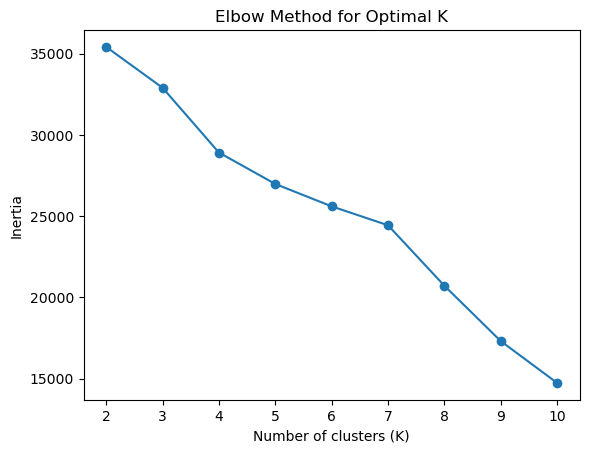

In [5]:
inertia = []
K_range = range(2, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(scaled_data)
    inertia.append(kmeans.inertia_)

# Plot the elbow curve
plt.plot(K_range, inertia, marker='o')
plt.title('Elbow Method for Optimal K')
plt.xlabel('Number of clusters (K)')
plt.ylabel('Inertia')
plt.show()


In [6]:
# Choose K=5 (based on elbow curve)
kmeans = KMeans(n_clusters=5, random_state=42)
kmeans_labels = kmeans.fit_predict(scaled_data)

# Compute silhouette score on a random subset (for memory efficiency)
sample_idx = np.random.choice(range(len(scaled_data)), size=800, replace=False)
sample_data = scaled_data[sample_idx]
sample_labels = kmeans_labels[sample_idx]

kmeans_silhouette = silhouette_score(sample_data, sample_labels)
print("Silhouette Score for K-Means:", kmeans_silhouette)


Silhouette Score for K-Means: 0.20532174308891882


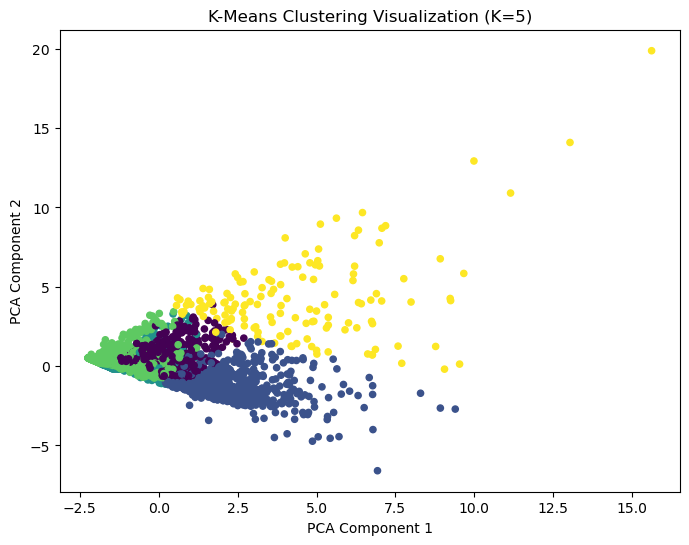

In [7]:
# PCA for visualization
pca = PCA(n_components=2)
pca_data = pca.fit_transform(scaled_data)

plt.figure(figsize=(8, 6))
plt.scatter(pca_data[:, 0], pca_data[:, 1], c=kmeans_labels, cmap='viridis', s=20)
plt.title('K-Means Clustering Visualization (K=5)')
plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')
plt.show()


In [8]:
# Apply DBSCAN with trial parameters
dbscan = DBSCAN(eps=1.8, min_samples=10)
dbscan_labels = dbscan.fit_predict(scaled_data)

# Count unique clusters
print("Unique Clusters in DBSCAN:", np.unique(dbscan_labels))


Unique Clusters in DBSCAN: [-1  0  1  2]


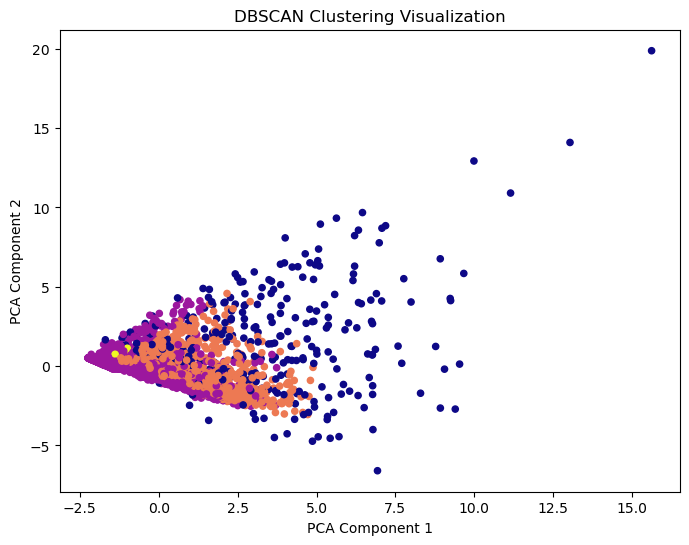

In [9]:
plt.figure(figsize=(8, 6))
plt.scatter(pca_data[:, 0], pca_data[:, 1], c=dbscan_labels, cmap='plasma', s=20)
plt.title('DBSCAN Clustering Visualization')
plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')
plt.show()


In [10]:
# Filter noise (-1) from DBSCAN before silhouette calculation
mask = dbscan_labels != -1
if len(set(dbscan_labels[mask])) > 1:
    dbscan_silhouette = silhouette_score(scaled_data[mask], dbscan_labels[mask])
    print("Silhouette Score for DBSCAN:", dbscan_silhouette)
else:
    print("DBSCAN did not form valid clusters for silhouette scoring.")


Silhouette Score for DBSCAN: 0.29050762433580474


Cluster Characteristics (K-Means):
                       Balance  Qual_miles  cc1_miles  cc2_miles  cc3_miles  \
KMeans_Cluster                                                               
0                58124.779499  193.427890   1.699642   1.019070   1.000000   
1               139193.010702  145.376932   4.195006   1.002378   1.057075   
2                59918.329626   70.803842   1.495450   1.020222   1.001011   
3                34546.727656   93.012648   1.247049   1.011804   1.000000   
4               196333.680556  773.805556   2.250000   1.041667   1.000000   

                 Bonus_miles  Bonus_trans  Flight_miles_12mo  Flight_trans_12  \
KMeans_Cluster                                                                  
0               10816.562574    10.760429         417.281287         1.258641   
1               51174.633769    20.095125         383.443520         1.166468   
2                6402.407482     8.601618         177.680485         0.528817   
3           

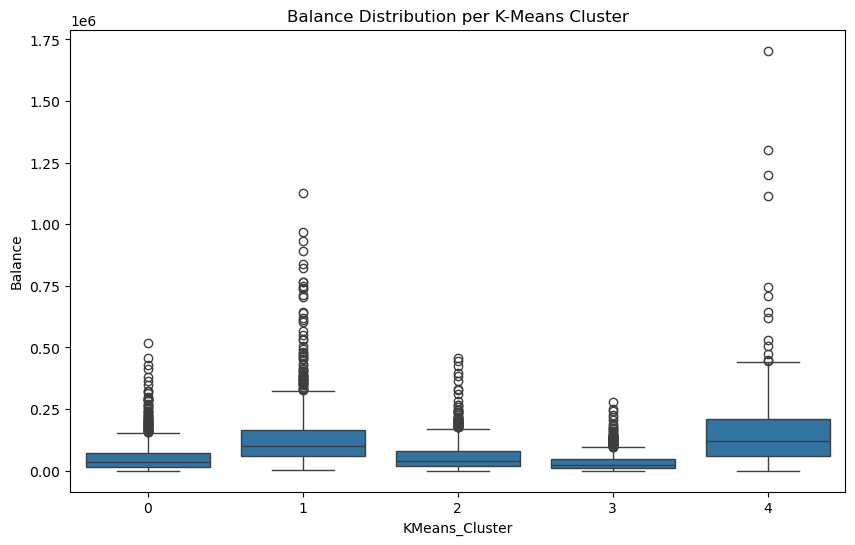

In [11]:
# cluster labels to dataframe
df['KMeans_Cluster'] = kmeans_labels
df['DBSCAN_Cluster'] = dbscan_labels

# Analyze cluster characteristics
cluster_summary = df.groupby('KMeans_Cluster').mean()
print("Cluster Characteristics (K-Means):\n", cluster_summary)

# Optional visualization
plt.figure(figsize=(10, 6))
sns.boxplot(x='KMeans_Cluster', y='Balance', data=df)
plt.title('Balance Distribution per K-Means Cluster')
plt.show()
